# Análise Exploratória - MovieLens

Objetivo: compreender o dataset e validar sua adequação para um sistema de recomendação.

Dataset: MovieLens Latest Small

Perguntas:
- Quantos usuários existem?
- Quantos filmes existem?
- Quantas interações existem?
- Como as avaliações estão distribuídas?
- Quais filmes são mais populares?

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [16]:
ratings = pd.read_csv("data/raw/ratings.csv")
movies = pd.read_csv("data/raw/movies.csv")

print(ratings.shape)
print(movies.shape)

(100836, 4)
(9742, 3)


In [17]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [18]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [19]:
print("Total de avaliações:", len(ratings))
print("Total de usuários:", ratings["userId"].nunique())
print("Total de filmes:", ratings["movieId"].nunique())
print("Nota média:", ratings["rating"].mean())

Total de avaliações: 100836
Total de usuários: 610
Total de filmes: 9724
Nota média: 3.501556983616962


In [20]:
ratings.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [21]:
movies.isnull().sum()

movieId    0
title      0
genres     0
dtype: int64

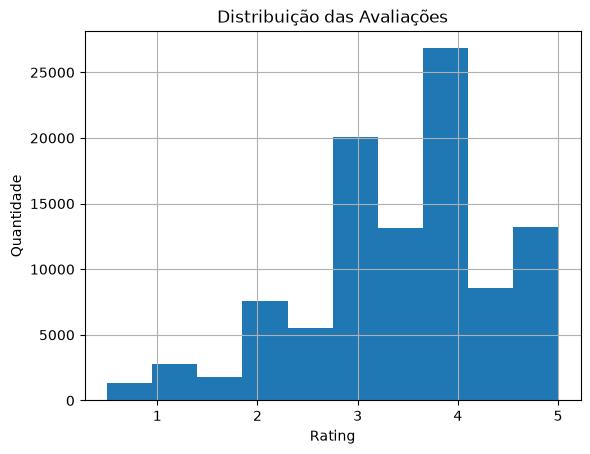

In [22]:
ratings["rating"].hist(bins=10)

plt.title("Distribuição das Avaliações")
plt.xlabel("Rating")
plt.ylabel("Quantidade")
plt.show()

In [23]:
user_activity = (
    ratings.groupby("userId")
    .size()
    .sort_values(ascending=False)
)

user_activity.head(10)

userId
414    2698
599    2478
474    2108
448    1864
274    1346
610    1302
68     1260
380    1218
606    1115
288    1055
dtype: int64

In [24]:
most_rated = (
    ratings.groupby("movieId")
    .size()
    .reset_index(name="total_ratings")
)

most_rated = (
    most_rated
    .merge(movies, on="movieId")
    .sort_values("total_ratings", ascending=False)
)

most_rated.head(10)

,movieId,total_ratings,title,genres
314,356,329,Forrest Gump (1994),Comedy|Drama|Romance|War
277,318,317,"Shawshank Redemption, The (1994)",Crime|Drama
257,296,307,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
510,593,279,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
1938,2571,278,"Matrix, The (1999)",Action|Sci-Fi|Thriller
224,260,251,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
418,480,238,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
97,110,237,Braveheart (1995),Action|Drama|War
507,589,224,Terminator 2: Judgment Day (1991),Action|Sci-Fi
461,527,220,Schindler's List (1993),Drama|War


In [25]:
movie_stats = (
    ratings.groupby("movieId")
    .agg(
        avg_rating=("rating", "mean"),
        total_ratings=("rating", "count")
    )
    .reset_index()
)

In [26]:
movie_stats = movie_stats[
    movie_stats["total_ratings"] >= 50
]

In [27]:
top_movies = (
    movie_stats
    .merge(movies, on="movieId")
    .sort_values(
        ["avg_rating", "total_ratings"],
        ascending=False
    )
)

top_movies.head(10)

,movieId,avg_rating,total_ratings,title,genres
53,318,4.429022,317,"Shawshank Redemption, The (1994)",Crime|Drama
118,858,4.289062,192,"Godfather, The (1972)",Crime|Drama
277,2959,4.272936,218,Fight Club (1999),Action|Crime|Drama|Thriller
171,1276,4.271930,57,Cool Hand Luke (1967),Drama
112,750,4.268041,97,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War
120,904,4.261905,84,Rear Window (1954),Mystery|Thriller
158,1221,4.259690,129,"Godfather: Part II, The (1974)",Crime|Drama
402,48516,4.252336,107,"Departed, The (2006)",Crime|Drama|Thriller
153,1213,4.250000,126,Goodfellas (1990),Crime|Drama
123,912,4.240000,100,Casablanca (1942),Drama|Romance


# Conclusões

- Dataset contém mais de 100 mil interações.
- Possui 610 usuários únicos.
- Possui mais de 9 mil filmes.
- Não foram encontrados problemas relevantes de qualidade.
- É adequado para construção de um sistema de recomendação.
- Como baseline inicial será utilizado um recomendador baseado em popularidade.